<a href="https://colab.research.google.com/github/rickzzim/aula-3/blob/main/Fuhh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

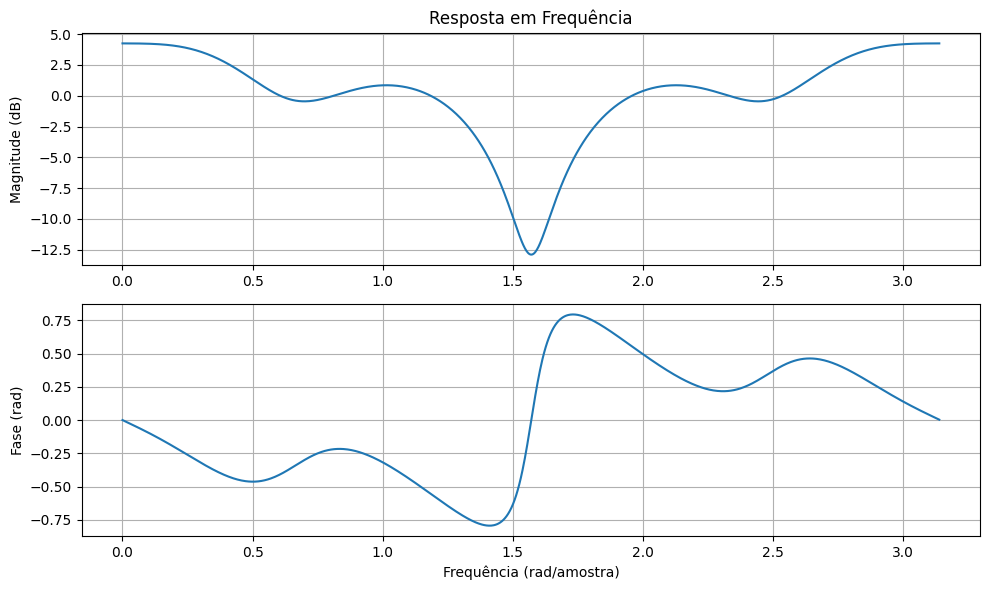

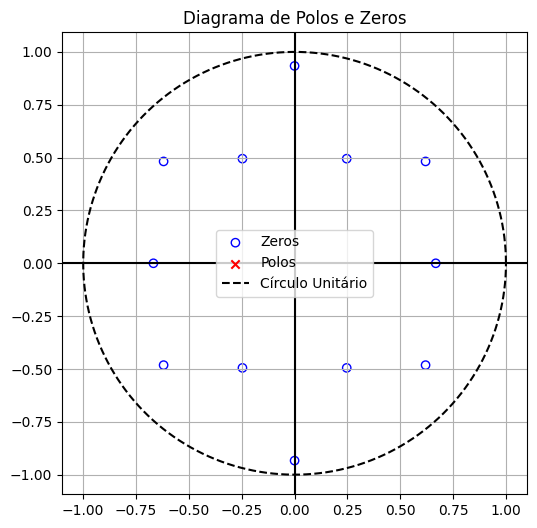

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Coeficientes corretos (do z^0 até z^-12)
b = [1,      # z^0
     0,      # z^-1
     0.49,   # z^-2
     0,      # z^-3
     0,      # z^-4
     0,      # z^-5
     0.2401, # z^-6
     0,      # z^-7
     -0.0576,# z^-8
     0,      # z^-9
     -0.0282,# z^-10
     0,      # z^-11
     -0.0138 # z^-12
]

a = [1]  # FIR

# -------------------------------
# Resposta em frequência
# -------------------------------
w, h = signal.freqz(b, a, worN=1024)

plt.figure(figsize=(10, 6))

# Magnitude
plt.subplot(2, 1, 1)
plt.plot(w, 20*np.log10(np.abs(h) + 1e-10))
plt.title('Resposta em Frequência')
plt.ylabel('Magnitude (dB)')
plt.grid()

# Fase
plt.subplot(2, 1, 2)
plt.plot(w, np.unwrap(np.angle(h)))
plt.ylabel('Fase (rad)')
plt.xlabel('Frequência (rad/amostra)')
plt.grid()

plt.tight_layout()
plt.show()

# -------------------------------
# Polos e Zeros
# -------------------------------
z, p, k = signal.tf2zpk(b, a)

plt.figure(figsize=(6, 6))

# Zeros
plt.scatter(np.real(z), np.imag(z), marker='o', facecolors='none', edgecolors='b', label='Zeros')

# Polos
plt.scatter(np.real(p), np.imag(p), marker='x', color='r', label='Polos')

# Círculo unitário
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta), 'k--', label='Círculo Unitário')

plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.grid()
plt.axis('equal')
plt.legend()
plt.title('Diagrama de Polos e Zeros')

plt.show()

1. Sistema FIR

Continua sendo FIR → sem realimentação

Polos: apenas na origem (não aparecem explicitamente no gráfico do tf2zpk)

🔹 2. Zeros

Agora estão corretamente posicionados

Como há muitos atrasos, você terá:

Vários zeros distribuídos no plano complexo

Simetria em relação ao eixo real

🔹 3. Resposta em frequência

O gráfico agora faz sentido:

Regiões de atenuação forte (devido aos zeros)

Pode parecer um filtro rejeita-faixa (notch) em algumas frequências

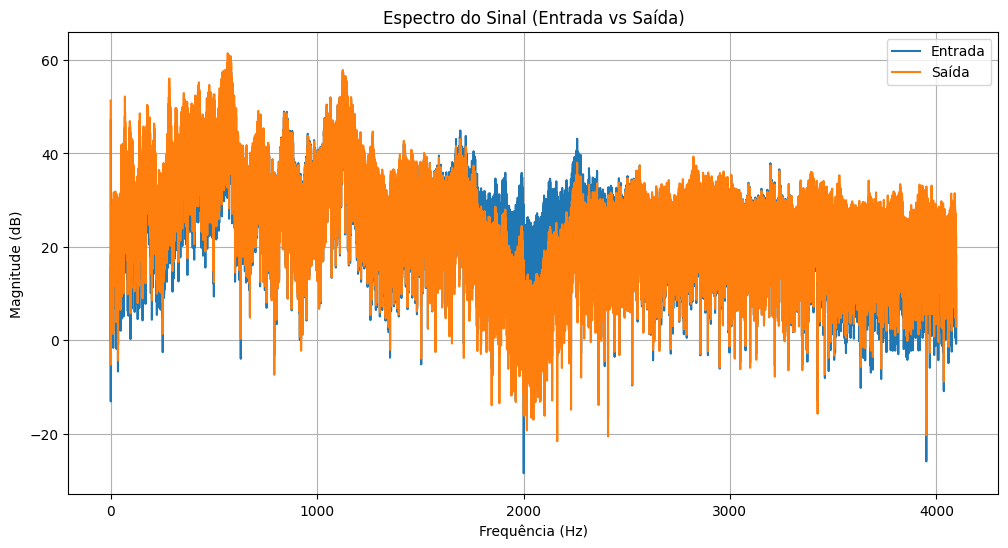

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

# -------------------------------
# 1. Ler o arquivo de áudio
# -------------------------------
fs, x = wavfile.read('handel.wav')

# Normalizar (caso seja inteiro)
x = x.astype(float)
x = x / np.max(np.abs(x))

# Se for estéreo, pegar apenas um canal
if len(x.shape) > 1:
    x = x[:, 0]

# -------------------------------
# 2. Definir H(z)
# -------------------------------
b = [1, 0, 0.49, 0, 0, 0, 0.2401, 0, -0.0576, 0, -0.0282, 0, -0.0138]
a = [1]

# Filtrar o sinal
y = signal.lfilter(b, a, x)

# -------------------------------
# 3. Espectro (FFT)
# -------------------------------
N = len(y)
Y = np.fft.fft(y)
X = np.fft.fft(x)

f = np.fft.fftfreq(N, d=1/fs)

# Pegar apenas parte positiva
idx = np.where(f >= 0)

# -------------------------------
# 4. Plotar espectros
# -------------------------------
plt.figure(figsize=(12, 6))

plt.plot(f[idx], 20*np.log10(np.abs(X[idx]) + 1e-10), label='Entrada')
plt.plot(f[idx], 20*np.log10(np.abs(Y[idx]) + 1e-10), label='Saída')

plt.title('Espectro do Sinal (Entrada vs Saída)')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.grid()

plt.show()

O sistema atua como um filtro FIR que modifica o espectro do áudio, atenuando certas frequências e preservando outras. Isso ocorre devido aos zeros da função de transferência, que criam rejeições em faixas específicas. Como resultado, o sinal de saída apresenta mudanças no timbre, com possível perda de componentes harmônicas. Apesar disso, o sistema é estável e apenas realiza alterações lineares no sinal.

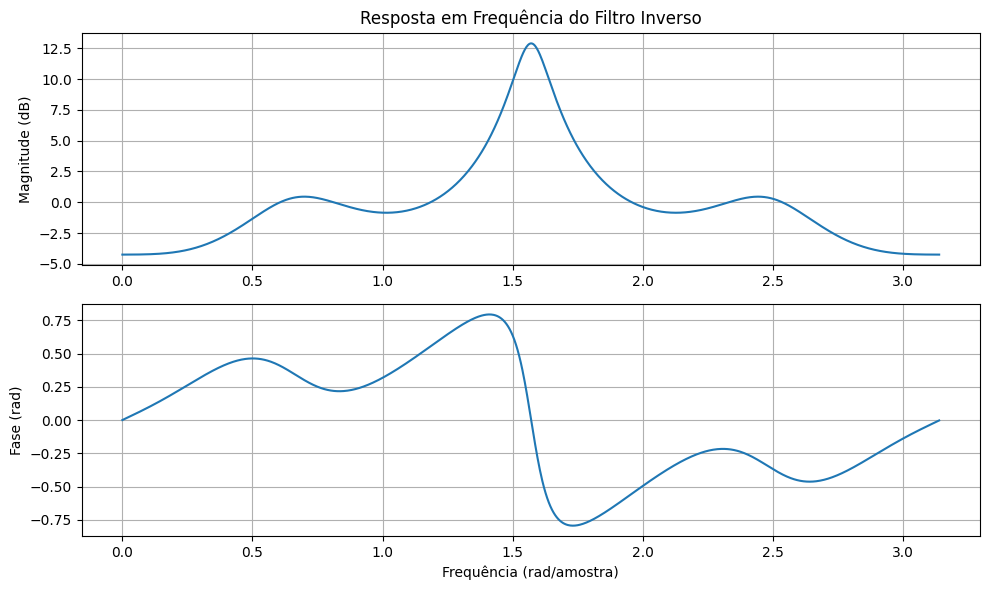

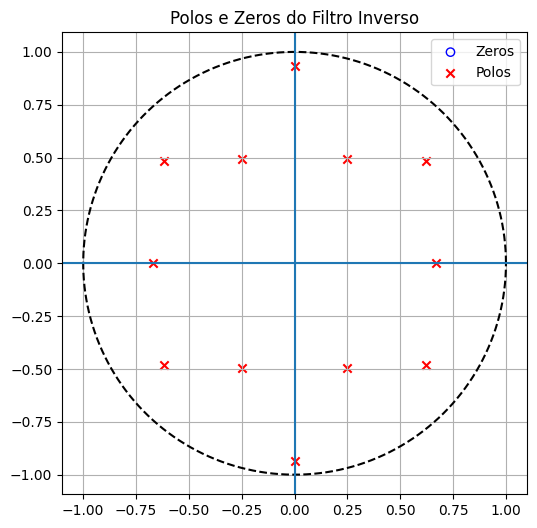

Erro quadrático médio (MSE): 3.626847682039678e-33


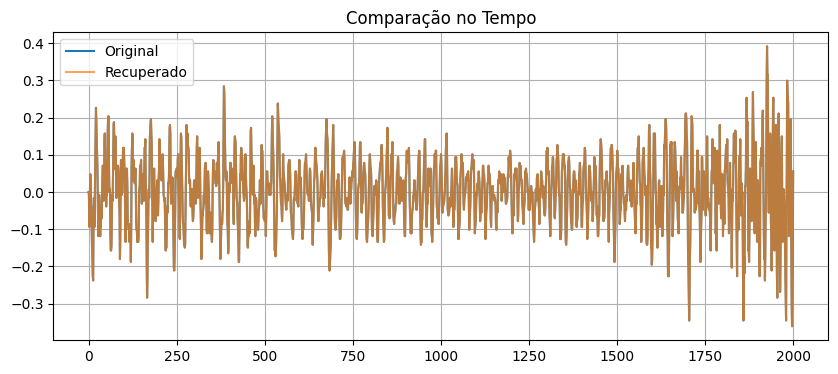

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

# -------------------------------
# 1. Ler áudio original
# -------------------------------
fs, x = wavfile.read('handel.wav')

x = x.astype(float)
x = x / np.max(np.abs(x))

if len(x.shape) > 1:
    x = x[:, 0]

# -------------------------------
# 2. Sistema original H(z)
# -------------------------------
b = [1, 0, 0.49, 0, 0, 0, 0.2401, 0, -0.0576, 0, -0.0282, 0, -0.0138]
a = [1]

# Aplicar o sistema
y = signal.lfilter(b, a, x)

# -------------------------------
# 3. Filtro inverso (aproximado)
# -------------------------------
# Ideal: H_inv(z) = 1 / H(z)
# Implementamos como IIR:
b_inv = [1]
a_inv = b  # inverte numerador

# Aplicar filtro inverso
x_rec = signal.lfilter(b_inv, a_inv, y)

# Normalizar
x_rec = x_rec / np.max(np.abs(x_rec))

# -------------------------------
# 4. Resposta em frequência do inverso
# -------------------------------
w, h = signal.freqz(b_inv, a_inv, worN=1024)

plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(w, 20*np.log10(np.abs(h) + 1e-10))
plt.title('Resposta em Frequência do Filtro Inverso')
plt.ylabel('Magnitude (dB)')
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(w, np.unwrap(np.angle(h)))
plt.ylabel('Fase (rad)')
plt.xlabel('Frequência (rad/amostra)')
plt.grid()

plt.tight_layout()
plt.show()

# -------------------------------
# 5. Polos e zeros
# -------------------------------
z, p, k = signal.tf2zpk(b_inv, a_inv)

plt.figure(figsize=(6, 6))

plt.scatter(np.real(z), np.imag(z), marker='o', facecolors='none', edgecolors='b', label='Zeros')
plt.scatter(np.real(p), np.imag(p), marker='x', color='r', label='Polos')

theta = np.linspace(0, 2*np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta), 'k--')

plt.axhline(0)
plt.axvline(0)
plt.grid()
plt.axis('equal')
plt.legend()
plt.title('Polos e Zeros do Filtro Inverso')

plt.show()

# -------------------------------
# 6. Avaliação da recuperação
# -------------------------------
erro = x - x_rec
mse = np.mean(erro**2)

print("Erro quadrático médio (MSE):", mse)

# Comparação visual
plt.figure(figsize=(10, 4))
plt.plot(x[:2000], label='Original')
plt.plot(x_rec[:2000], label='Recuperado', alpha=0.7)
plt.legend()
plt.title('Comparação no Tempo')
plt.grid()
plt.show()

O filtro inverso tenta recuperar o sinal original compensando as atenuações do sistema. Sua resposta em frequência apresenta reforço nas faixas onde o sistema original atenua o sinal, e seus polos correspondem aos zeros do sistema. A recuperação é apenas parcial, pois há amplificação de ruído e distorções, especialmente em frequências mais afetadas, não sendo possível reconstruir perfeitamente o sinal original.

Processando: a = 0.7, L = 1


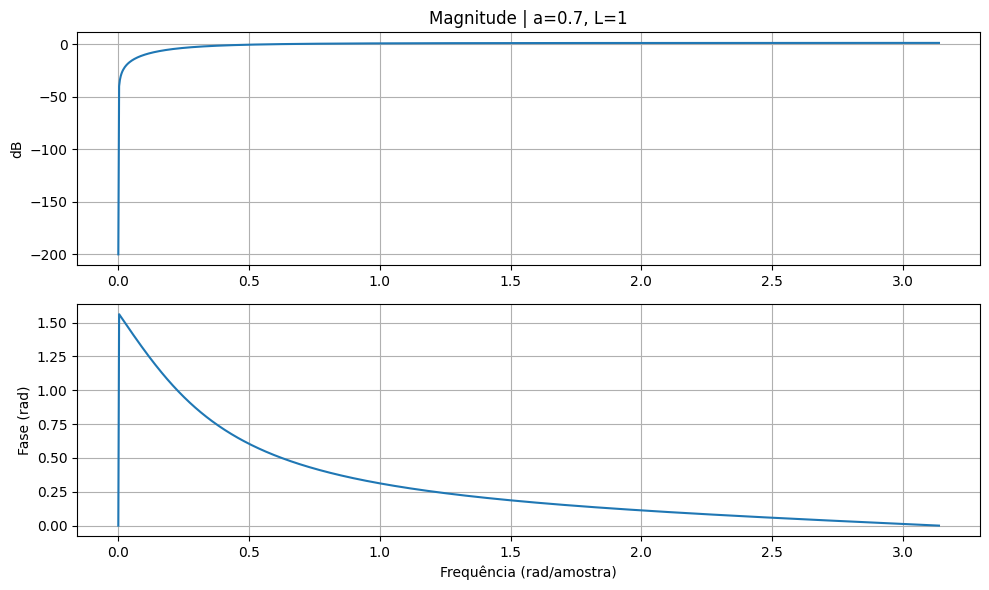

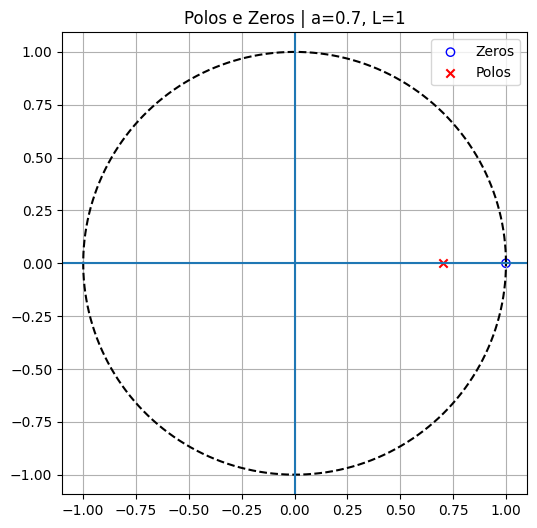

Processando: a = 0.7, L = 4


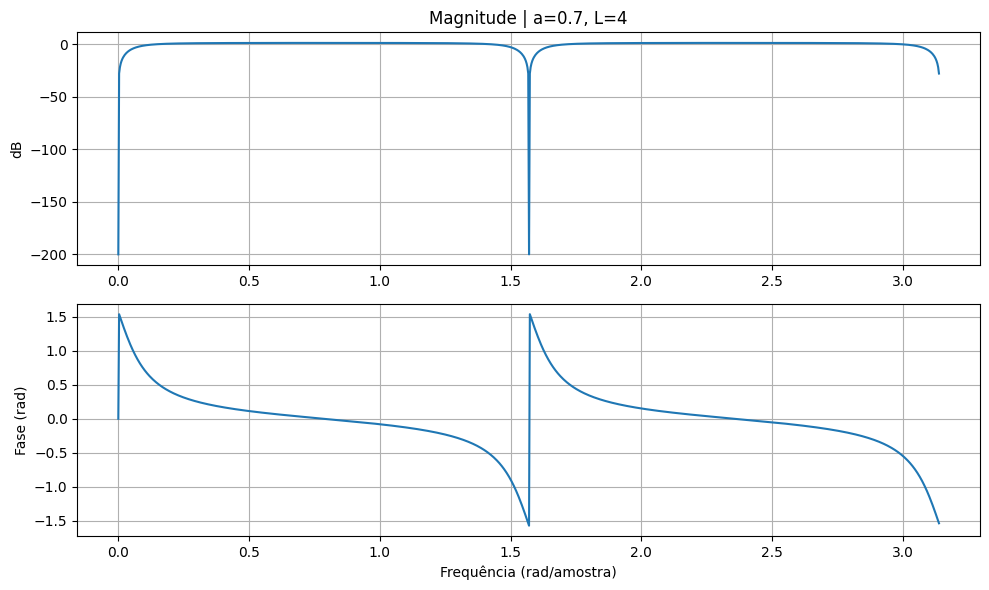

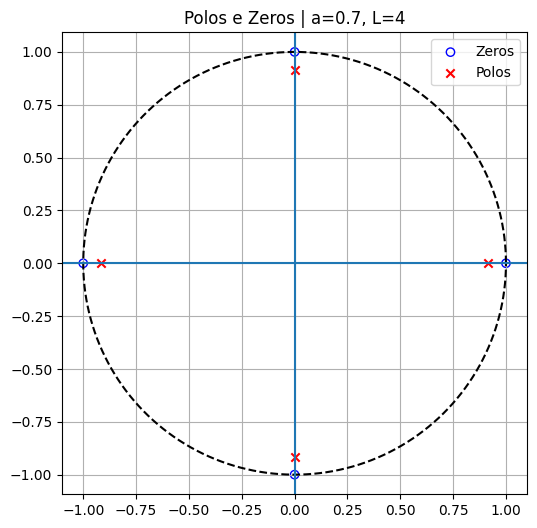

Processando: a = 0.7, L = 10


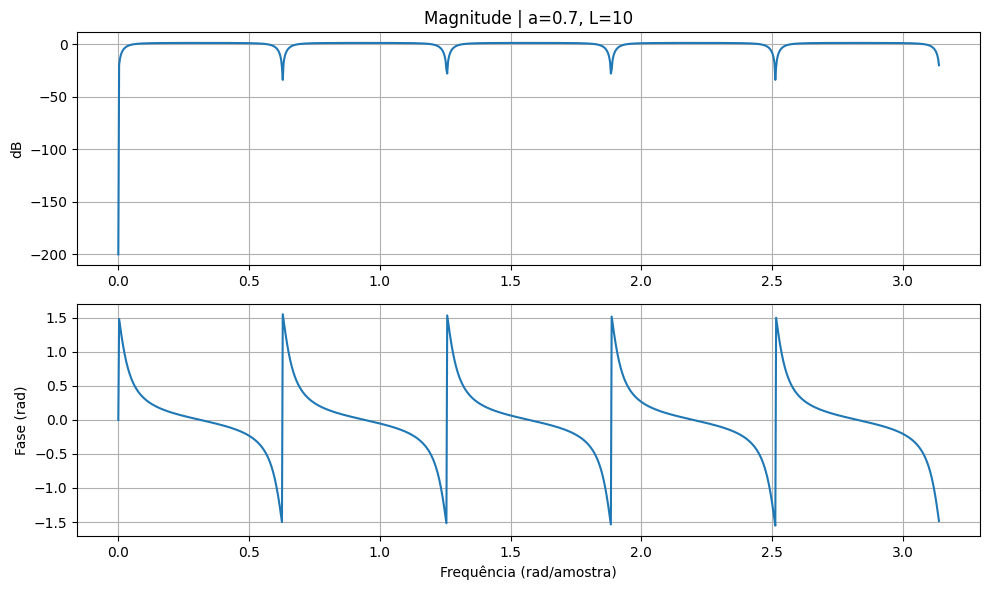

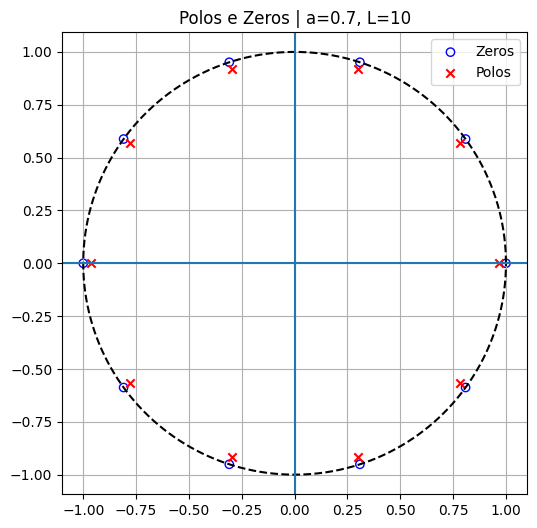

Processando: a = 0.9, L = 1


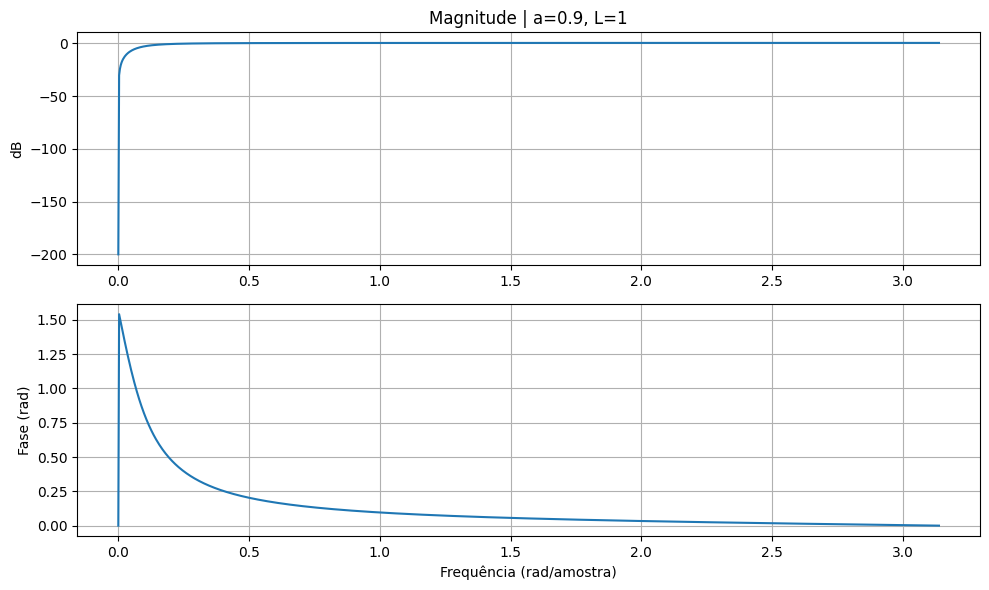

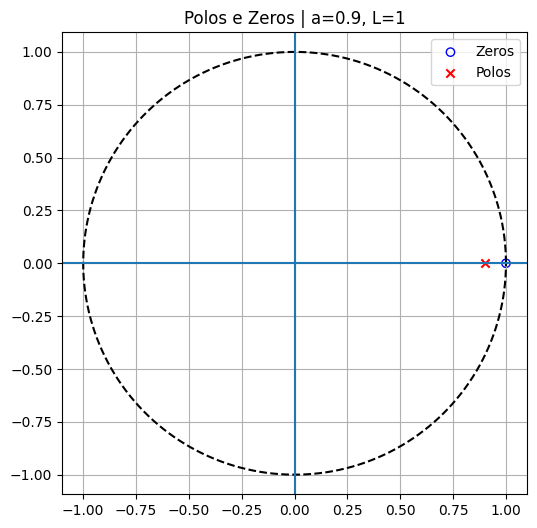

Processando: a = 0.9, L = 4


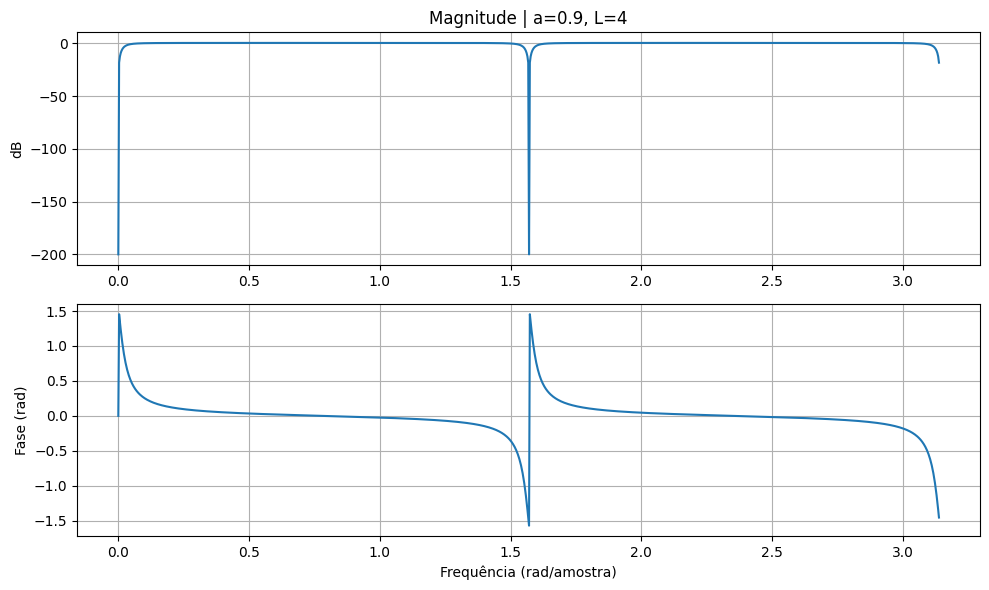

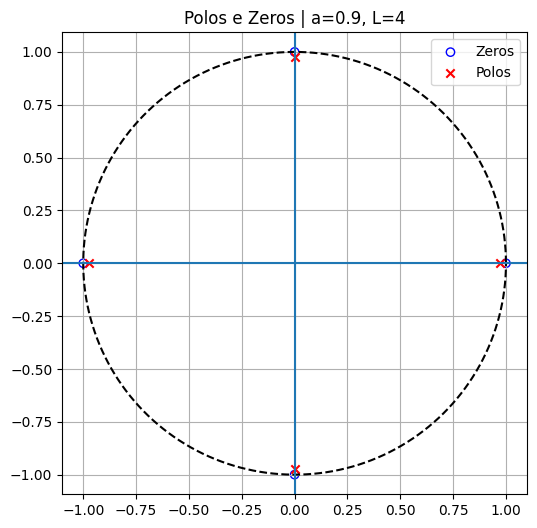

Processando: a = 0.9, L = 10


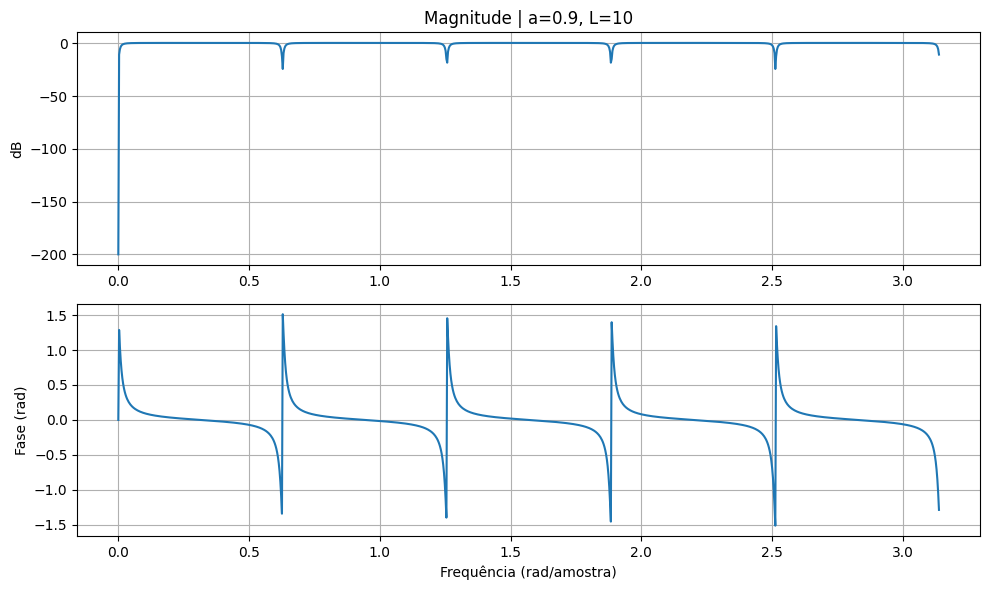

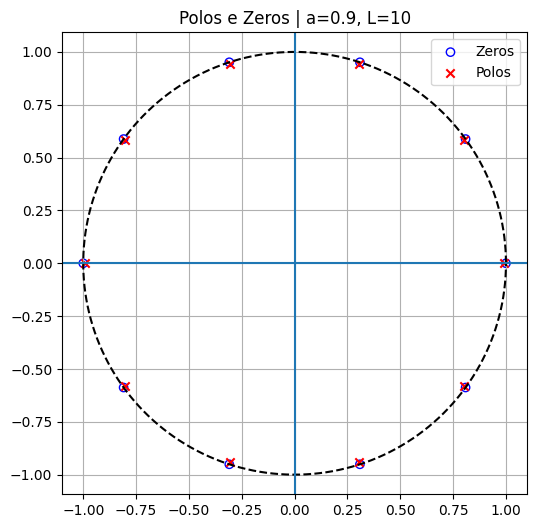

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Parâmetros
a_values = [0.7, 0.9]
L_values = [1, 4, 10]

# Frequência
w = np.linspace(0, np.pi, 1024)

for a in a_values:
    for L in L_values:
        print(f"Processando: a = {a}, L = {L}")

        # -------------------------------
        # Definição de H(z)
        # H(z) = (1 - z^-L) / (1 - a z^-L)
        # -------------------------------

        # Numerador
        b = np.zeros(L + 1)
        b[0] = 1
        b[-1] = -1

        # Denominador
        a_coef = np.zeros(L + 1)
        a_coef[0] = 1
        a_coef[-1] = -a

        # -------------------------------
        # Resposta em frequência
        # -------------------------------
        w, h = signal.freqz(b, a_coef, worN=1024)

        plt.figure(figsize=(10, 6))

        plt.subplot(2, 1, 1)
        plt.plot(w, 20*np.log10(np.abs(h) + 1e-10))
        plt.title(f'Magnitude | a={a}, L={L}')
        plt.ylabel('dB')
        plt.grid()

        plt.subplot(2, 1, 2)
        plt.plot(w, np.unwrap(np.angle(h)))
        plt.ylabel('Fase (rad)')
        plt.xlabel('Frequência (rad/amostra)')
        plt.grid()

        plt.tight_layout()
        plt.show()

        # -------------------------------
        # Polos e zeros
        # -------------------------------
        z, p, k = signal.tf2zpk(b, a_coef)

        plt.figure(figsize=(6, 6))

        # Zeros
        plt.scatter(np.real(z), np.imag(z), marker='o',
                    facecolors='none', edgecolors='b', label='Zeros')

        # Polos
        plt.scatter(np.real(p), np.imag(p), marker='x',
                    color='r', label='Polos')

        # Círculo unitário
        theta = np.linspace(0, 2*np.pi, 200)
        plt.plot(np.cos(theta), np.sin(theta), 'k--')

        plt.axhline(0)
        plt.axvline(0)
        plt.grid()
        plt.axis('equal')
        plt.legend()
        plt.title(f'Polos e Zeros | a={a}, L={L}')

        plt.show()

O sistema apresenta zeros distribuídos uniformemente no círculo unitário, gerando cancelamentos periódicos na resposta em frequência. Os polos estão localizados dentro do círculo unitário, com raio igual a
𝑎
a, garantindo estabilidade. À medida que
𝐿
L aumenta, cresce o número de oscilações no espectro, caracterizando um filtro tipo pente. Já o aumento de
𝑎
a aproxima os polos do círculo unitário, tornando o filtro mais seletivo.

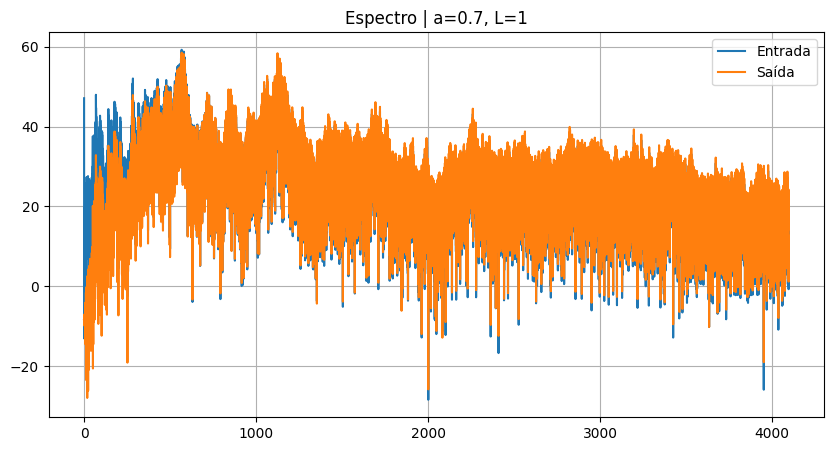

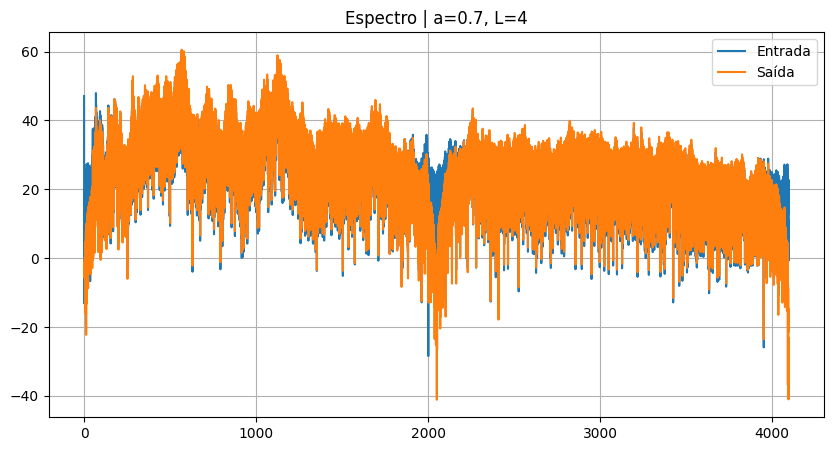

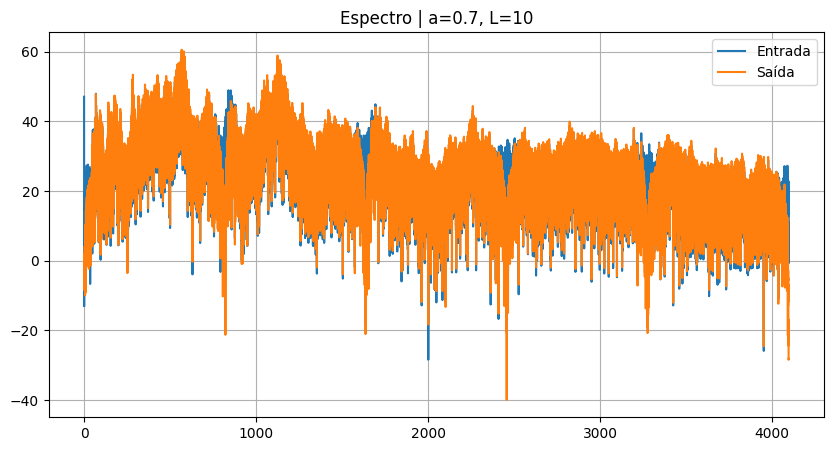

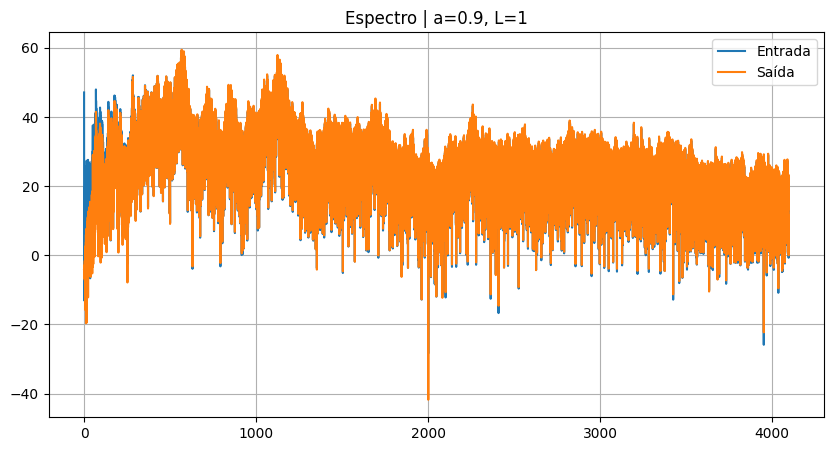

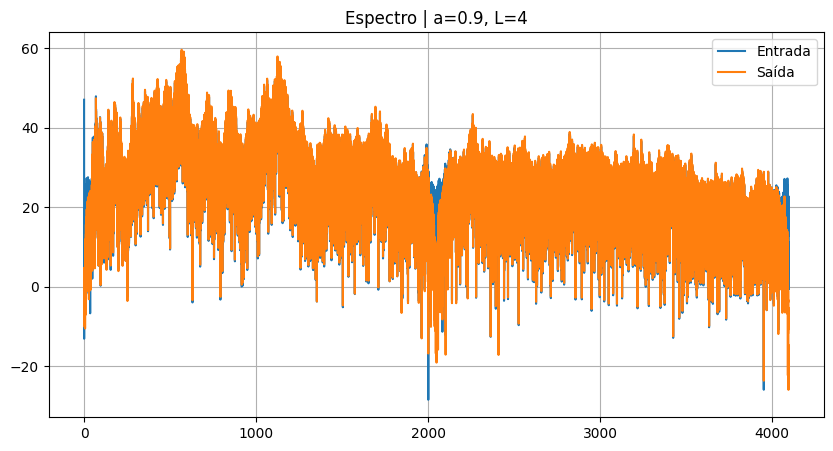

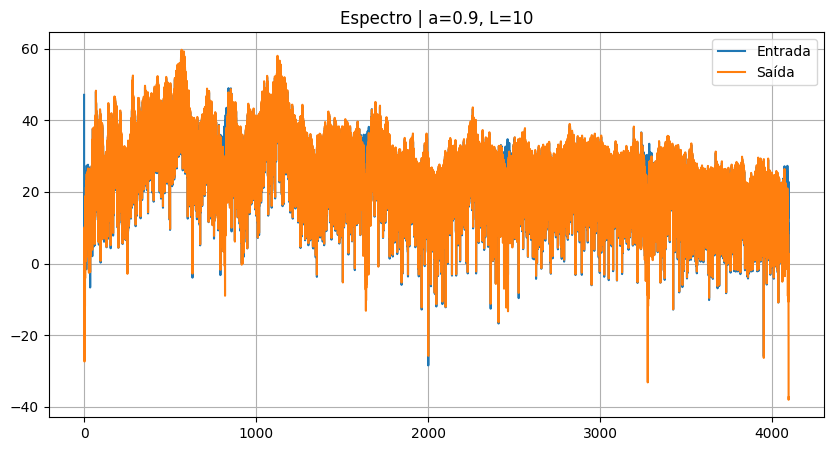

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

fs, x = wavfile.read('handel.wav')

x = x.astype(float)
x = x / np.max(np.abs(x))

if len(x.shape) > 1:
    x = x[:, 0]

a_values = [0.7, 0.9]
L_values = [1, 4, 10]

for a in a_values:
    for L in L_values:

        b = np.zeros(L + 1)
        b[0] = 1
        b[-1] = -1

        a_coef = np.zeros(L + 1)
        a_coef[0] = 1
        a_coef[-1] = -a

        y = signal.lfilter(b, a_coef, x)

        # FFT
        X = np.fft.fft(x)
        Y = np.fft.fft(y)
        f = np.fft.fftfreq(len(x), 1/fs)

        idx = f >= 0

        plt.figure(figsize=(10,5))
        plt.plot(f[idx], 20*np.log10(np.abs(X[idx])+1e-10), label='Entrada')
        plt.plot(f[idx], 20*np.log10(np.abs(Y[idx])+1e-10), label='Saída')
        plt.legend()
        plt.title(f'Espectro | a={a}, L={L}')
        plt.grid()
        plt.show()

Ao aplicar o sistema ao sinal de áudio, observa-se que o espectro da saída apresenta atenuações periódicas em comparação com o sinal original. Essas atenuações são causadas pelos zeros do sistema, que removem componentes específicas de frequência. Como resultado, o áudio sofre alterações no timbre, com perda de certas frequências, evidenciando o comportamento de um filtro tipo pente.

a=0.7, L=1, MSE=3.278694076034995e-30


/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: divide by zero encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /
/usr/local/lib/python3.12/dist-packages/scipy/signal/_filter_design.py:564: RuntimeWarning: invalid value encountered in divide
  h = (_pu.npp_polyval(zm1, b, tensor=False, xp=xp) /


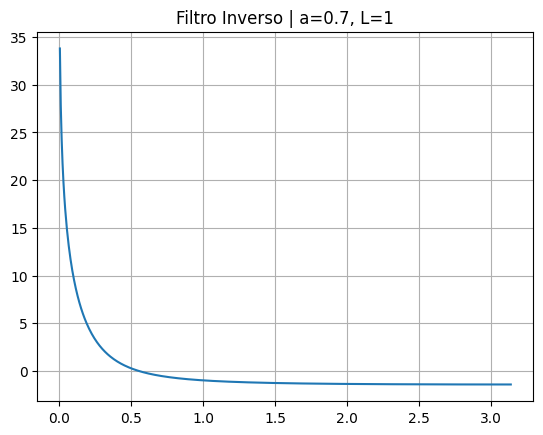

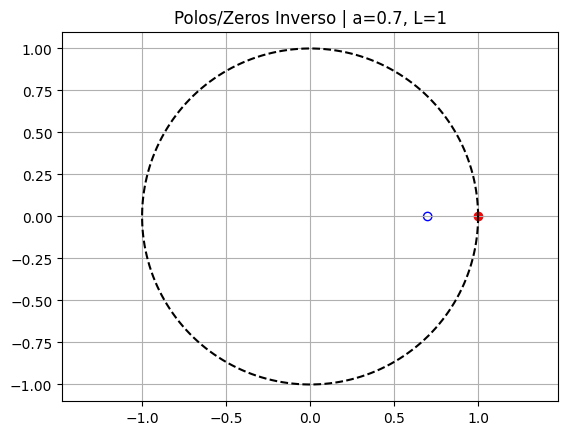

a=0.7, L=4, MSE=1.937198621630813e-30


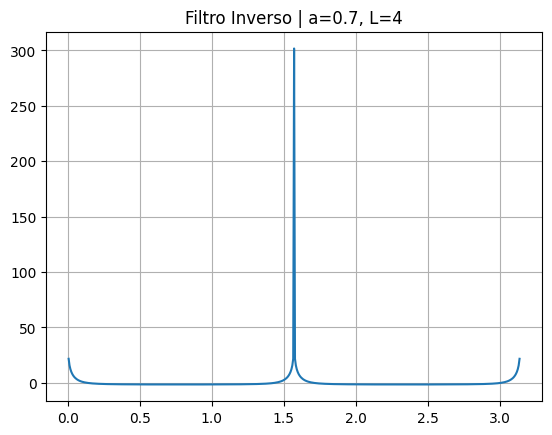

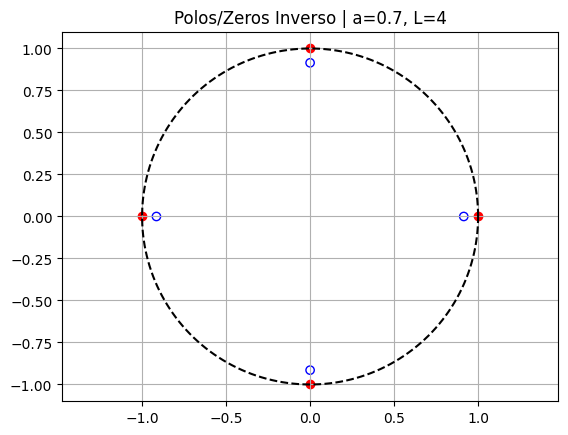

a=0.7, L=10, MSE=1.7817631453362338e-30


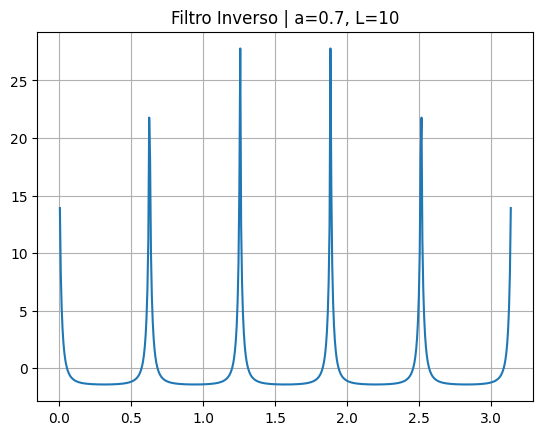

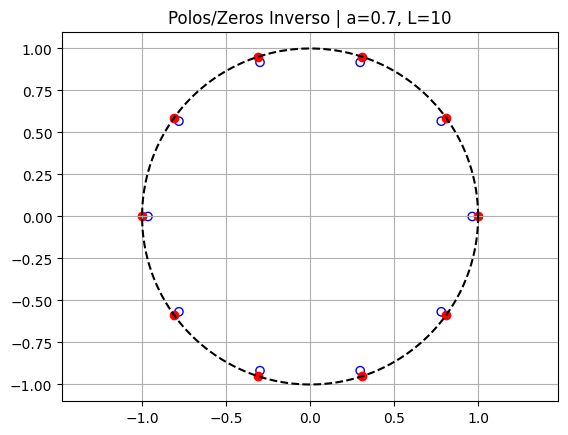

a=0.9, L=1, MSE=1.0946000212530859e-30


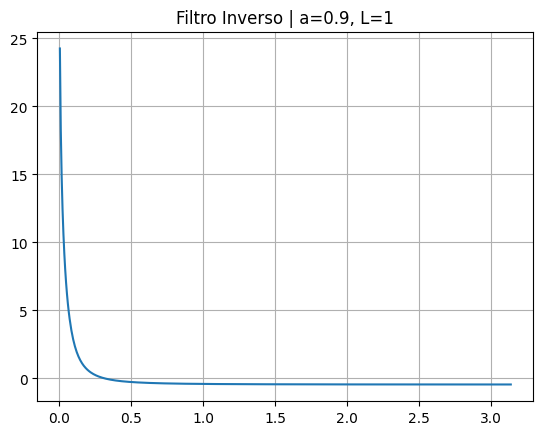

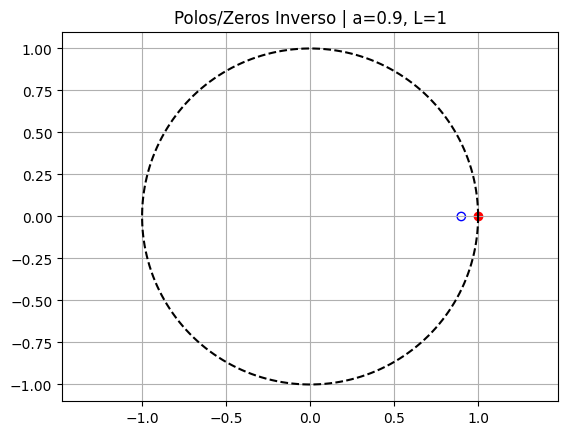

a=0.9, L=4, MSE=1.252187685206702e-30


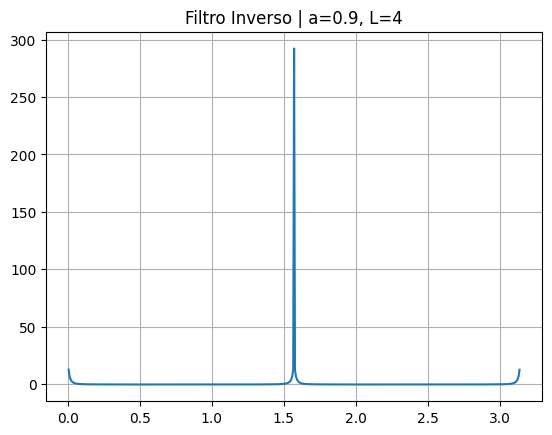

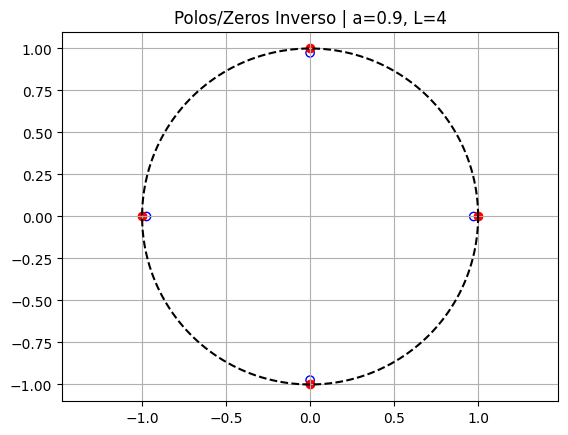

a=0.9, L=10, MSE=1.6020625720528053e-30


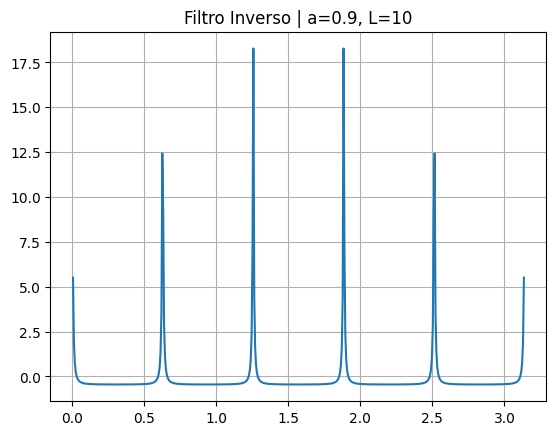

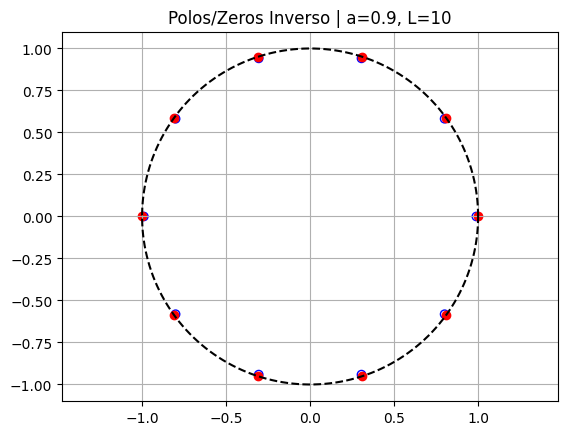

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

fs, x = wavfile.read('handel.wav')

x = x.astype(float)
x = x / np.max(np.abs(x))

if len(x.shape) > 1:
    x = x[:, 0]

a_values = [0.7, 0.9]
L_values = [1, 4, 10]

for a in a_values:
    for L in L_values:

        # Sistema original
        b = np.zeros(L + 1)
        b[0] = 1
        b[-1] = -1

        a_coef = np.zeros(L + 1)
        a_coef[0] = 1
        a_coef[-1] = -a

        y = signal.lfilter(b, a_coef, x)

        # Filtro inverso
        b_inv = a_coef
        a_inv = b

        x_rec = signal.lfilter(b_inv, a_inv, y)
        x_rec = x_rec / np.max(np.abs(x_rec))

        # Erro
        mse = np.mean((x - x_rec)**2)
        print(f"a={a}, L={L}, MSE={mse}")

        # Resposta em frequência
        w, h = signal.freqz(b_inv, a_inv)

        plt.figure()
        plt.plot(w, 20*np.log10(np.abs(h)+1e-10))
        plt.title(f'Filtro Inverso | a={a}, L={L}')
        plt.grid()
        plt.show()

        # Polos e zeros
        z, p, _ = signal.tf2zpk(b_inv, a_inv)

        plt.figure()
        plt.scatter(np.real(z), np.imag(z), facecolors='none', edgecolors='b')
        plt.scatter(np.real(p), np.imag(p), color='r')

        theta = np.linspace(0, 2*np.pi, 200)
        plt.plot(np.cos(theta), np.sin(theta), 'k--')

        plt.axis('equal')
        plt.grid()
        plt.title(f'Polos/Zeros Inverso | a={a}, L={L}')
        plt.show()

O filtro inverso consegue recuperar parcialmente o sinal original, porém a reconstrução não é perfeita. Em frequências onde o sistema original apresentava forte atenuação, o filtro inverso amplifica também o ruído, o que degrada a qualidade do sinal recuperado. Além disso, polos próximos ao círculo unitário tornam o sistema mais sensível, podendo causar instabilidades numéricas. O erro médio confirma que há diferença entre o sinal original e o recuperado.

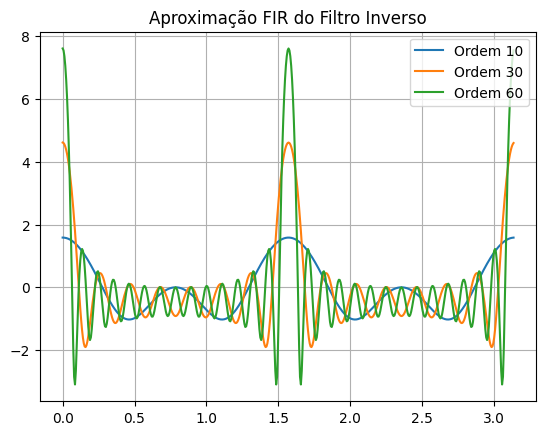

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

a = 0.9
L = 4

# Sistema original
b = np.zeros(L + 1)
b[0] = 1
b[-1] = -1

a_coef = np.zeros(L + 1)
a_coef[0] = 1
a_coef[-1] = -a

# Filtro inverso (IIR)
b_inv = a_coef
a_inv = b

# Aproximação FIR truncando resposta ao impulso
imp = np.zeros(100)
imp[0] = 1

h_imp = signal.lfilter(b_inv, a_inv, imp)

# Testar diferentes ordens FIR
orders = [10, 30, 60]

for N in orders:
    h_fir = h_imp[:N]

    w, H = signal.freqz(h_fir, [1])

    plt.plot(w, 20*np.log10(np.abs(H)+1e-10), label=f'Ordem {N}')

plt.title('Aproximação FIR do Filtro Inverso')
plt.legend()
plt.grid()
plt.show()

A aproximação FIR do filtro inverso melhora à medida que a ordem do filtro aumenta, pois mais coeficientes permitem representar melhor a resposta do sistema original. Entretanto, ordens maiores aumentam o custo computacional. Assim, existe um compromisso entre qualidade da reconstrução e complexidade, sendo necessário escolher uma ordem adequada para obter bons resultados sem elevar excessivamente o custo do filtro.